In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simulate_eeg import simulate_data
from heterorc import HeteroRC, time_resolved_decoding_heterorc  
from heterorc_interpretation import analyze_dynamics            


Posterior Channels (14): ['CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']


In [2]:
''' Single-subj Data simulation '''
# X: (n_trials, n_channels, n_times)
# y: (n_trials,)
# times: (n_times,)

# erp simulation during 0.2-0.6s
X, y, times = simulate_data(sub_id=1, mode='erp', 
                            sfreq=100,
                            tmin=0,
                            tmax=0.8,
                            n_trials=60, # total trials
                            n_channels=32,
                            n_classes=2)

fs = 1.0 / np.mean(np.diff(times))  # sampling rate

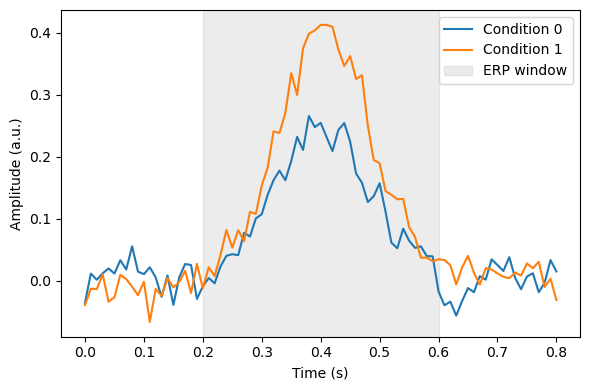

In [3]:
''' ERP univariate '''
cond0 = X[y == 0]   # (n0, ch, t)
cond1 = X[y == 1]
erp0 = cond0.mean(axis=0).mean(axis=0)   # (t,)
erp1 = cond1.mean(axis=0).mean(axis=0)
plt.figure(figsize=(6, 4))
plt.plot(times, erp0, label="Condition 0")
plt.plot(times, erp1, label="Condition 1")
plt.axvspan(0.2, 0.6, color="gray", alpha=0.15, label="ERP window")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
''' HeteroRC time-resolved decoding '''
rc_params = dict(
    n_res=350, # smaller for low SNR or few trials; larger for richer dynamics. Recommendation: ~10x n_channels
    fs=fs,
    spectral_radius=0.95, # Recommendation: 0.8–0.99 [less impactful for decoding results]
    input_scaling=0.5, # May influence results. larger for more non-linear dynamics
    bias_scaling=0.5, # May influence results too.
    tau_mode=0.01,
    tau_sigma=0.8,
    tau_min=0.002,
    tau_max=0.08,
    bidirectional=True,
    merge_mode="product",
)

# parameters for smoothing decision scores
FWHM_MS = 25.0  # 25ms
sigma_points = (FWHM_MS / 2.355 / 1000.0) * fs
# run decoding
acc = time_resolved_decoding_heterorc(
    X=X, y=y, times=times,
    n_folds=5,
    rc_params=rc_params,
    metric="accuracy",
    rc_seed_mode="fixed", 
    smooth_decisions=True,
    smooth_sigma_points=sigma_points,
    verbose=True,
)



Fold 1/5 done. scale=1.93
Fold 2/5 done. scale=1.94
Fold 3/5 done. scale=1.93
Fold 4/5 done. scale=1.93
Fold 5/5 done. scale=1.93


Peak decoding: 0.9333333333333332 at 0.41000000000000003 s


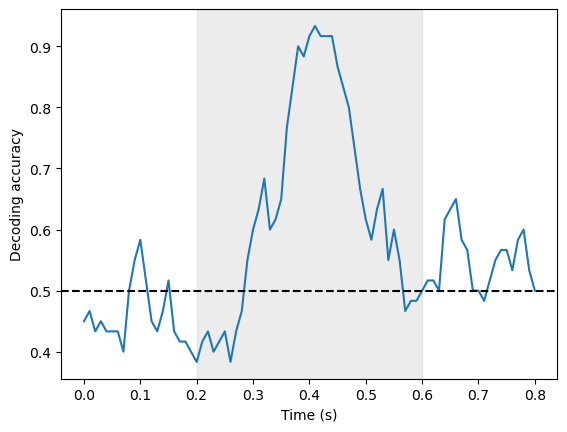

In [5]:
''' Results & plotting '''
peak_idx = int(np.argmax(acc))
peak_time = float(times[peak_idx])
print("Peak decoding:", acc[peak_idx], "at", peak_time, "s")
plt.figure()
plt.plot(times, acc)
plt.axvspan(0.2, 0.6, color="gray", alpha=0.15, label="ERP window")
plt.axhline(0.5, linestyle="--",color='k')
plt.xlabel("Time (s)")
plt.ylabel("Decoding accuracy")
plt.show()